In [5]:
import os
os.environ['KAGGLE_USERNAME'] = "ronsardcarnegie"
os.environ['KAGGLE_KEY'] = "2da9b58e9e4564beccb26ce74d05b24e"

!pip install -q kaggle
!kaggle datasets download -d splcher/animefacedataset -p /content/dataset
!unzip -q /content/dataset/animefacedataset.zip -d /content/dataset

# Check actual folder structure
for root, dirs, files in os.walk("/content/dataset"):
    print(root, "->", len(files), "files")

Dataset URL: https://www.kaggle.com/datasets/splcher/animefacedataset
License(s): DbCL-1.0
100% 395M/395M [00:07<00:00, 56.1MB/s]

/content/dataset -> 1 files
/content/dataset/images -> 63565 files


Number of images: 63565


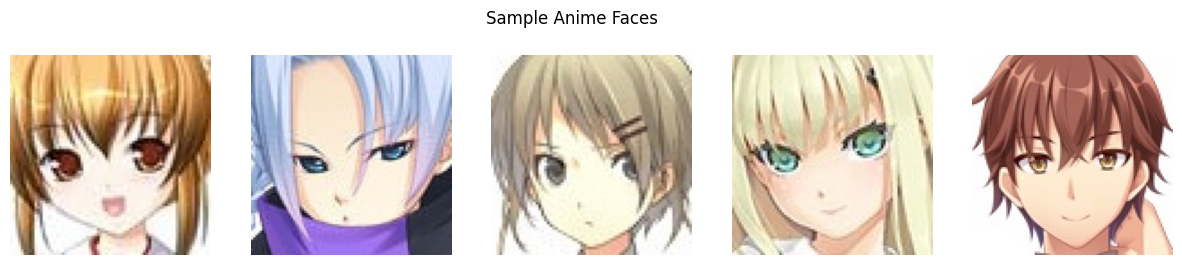

In [5]:
import os
import matplotlib.pyplot as plt
from PIL import Image

img_dir = "/content/dataset/images"
files = os.listdir(img_dir)
print(f"Number of images: {len(files)}")

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    img = Image.open(os.path.join(img_dir, files[i]))
    ax.imshow(img)
    ax.axis('off')
plt.suptitle("Sample Anime Faces")
plt.show()

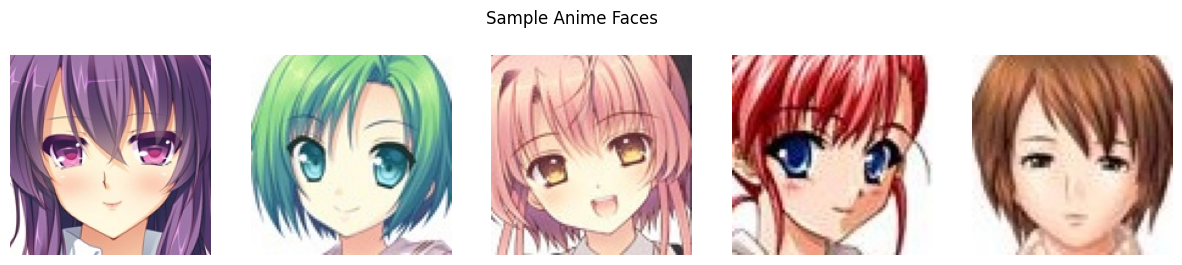

In [13]:
import random
sample_files = random.sample(files, 5)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    img = Image.open(os.path.join(img_dir, sample_files[i]))
    ax.imshow(img)
    ax.axis('off')
plt.suptitle("Sample Anime Faces")
plt.show()

In [1]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

LATENT_DIM = 100
IMG_CHANNELS = 3
FEATURE_MAP_SIZE = 64  # base feature map depth

class Generator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, feature_map_size=FEATURE_MAP_SIZE, img_channels=IMG_CHANNELS):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # input: latent_dim x 1 x 1
            nn.ConvTranspose2d(latent_dim, feature_map_size * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feature_map_size * 8),
            nn.ReLU(True),
            # state: (fm*8) x 4 x 4

            nn.ConvTranspose2d(feature_map_size * 8, feature_map_size * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_map_size * 4),
            nn.ReLU(True),
            # state: (fm*4) x 8 x 8

            nn.ConvTranspose2d(feature_map_size * 4, feature_map_size * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_map_size * 2),
            nn.ReLU(True),
            # state: (fm*2) x 16 x 16

            nn.ConvTranspose2d(feature_map_size * 2, feature_map_size, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_map_size),
            nn.ReLU(True),
            # state: (fm) x 32 x 32

            nn.ConvTranspose2d(feature_map_size, img_channels, 4, 2, 1, bias=False),
            nn.Tanh()
            # output: img_channels x 64 x 64
        )

    def forward(self, x):
        return self.main(x)


class Discriminator(nn.Module):
    def __init__(self, feature_map_size=FEATURE_MAP_SIZE, img_channels=IMG_CHANNELS):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # input: img_channels x 64 x 64
            nn.Conv2d(img_channels, feature_map_size, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state: (fm) x 32 x 32

            nn.Conv2d(feature_map_size, feature_map_size * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_map_size * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state: (fm*2) x 16 x 16

            nn.Conv2d(feature_map_size * 2, feature_map_size * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_map_size * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state: (fm*4) x 8 x 8

            nn.Conv2d(feature_map_size * 4, feature_map_size * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_map_size * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # state: (fm*8) x 4 x 4

            nn.Conv2d(feature_map_size * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
            # output: 1 x 1 x 1
        )

    def forward(self, x):
        return self.main(x).view(-1, 1).squeeze(1)


# Weight initialization (DCGAN paper recommendation)
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# Instantiate
generator = Generator().to(device)
discriminator = Discriminator().to(device)
generator.apply(weights_init)
discriminator.apply(weights_init)

print(generator)
print(discriminator)

Using device: cuda
Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    

In [2]:
# Sanity check: fake noise -> generator -> discriminator
test_noise = torch.randn(8, LATENT_DIM, 1, 1, device=device)
fake_images = generator(test_noise)
print(f"Generator output shape: {fake_images.shape}")  # expect [8, 3, 64, 64]

disc_output = discriminator(fake_images)
print(f"Discriminator output shape: {disc_output.shape}")  # expect [8]
print(f"Discriminator output values (should be ~0.5 range, untrained): {disc_output}")

Generator output shape: torch.Size([8, 3, 64, 64])
Discriminator output shape: torch.Size([8])
Discriminator output values (should be ~0.5 range, untrained): tensor([0.3806, 0.3242, 0.2415, 0.4840, 0.5718, 0.5329, 0.2916, 0.6421],
       device='cuda:0', grad_fn=<SqueezeBackward1>)


In [6]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

IMG_DIR = "/content/dataset/images"
BATCH_SIZE = 128
IMAGE_SIZE = 64

class AnimeFaceDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.files = os.listdir(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.files[idx])
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img

transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)  # scale to [-1, 1] to match generator's tanh output
])

train_dataset = AnimeFaceDataset(IMG_DIR, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)

print(f"Dataset size: {len(train_dataset)}")
print(f"Number of batches: {len(train_loader)}")

# Sanity check one batch
sample_batch = next(iter(train_loader))
print(f"Batch shape: {sample_batch.shape}")  # expect [128, 3, 64, 64]
print(f"Value range: [{sample_batch.min():.2f}, {sample_batch.max():.2f}]")  # expect ~[-1, 1]

Dataset size: 63565
Number of batches: 496
Batch shape: torch.Size([128, 3, 64, 64])
Value range: [-1.00, 1.00]


In [7]:
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import time

# Hyperparameters
NUM_EPOCHS = 30
LR = 0.0002
BETA1 = 0.5

criterion = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=LR, betas=(BETA1, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR, betas=(BETA1, 0.999))

# Fixed noise to track the SAME latent vectors across epochs (for the progression grid)
fixed_noise = torch.randn(64, LATENT_DIM, 1, 1, device=device)

REAL_LABEL = 1.0
FAKE_LABEL = 0.0

G_losses = []
D_losses = []
checkpoint_grids = []

print("Starting training...")
start_time = time.time()

for epoch in range(NUM_EPOCHS):
    for i, real_images in enumerate(train_loader):
        real_images = real_images.to(device)
        b_size = real_images.size(0)

        # ----- Train Discriminator: maximize log(D(x)) + log(1 - D(G(z))) -----
        discriminator.zero_grad()

        label = torch.full((b_size,), REAL_LABEL, dtype=torch.float, device=device)
        output_real = discriminator(real_images)
        loss_D_real = criterion(output_real, label)
        loss_D_real.backward()

        noise = torch.randn(b_size, LATENT_DIM, 1, 1, device=device)
        fake_images = generator(noise)
        label.fill_(FAKE_LABEL)
        output_fake = discriminator(fake_images.detach())
        loss_D_fake = criterion(output_fake, label)
        loss_D_fake.backward()

        loss_D = loss_D_real + loss_D_fake
        optimizer_D.step()

        # ----- Train Generator: maximize log(D(G(z))) -----
        generator.zero_grad()
        label.fill_(REAL_LABEL)  # generator wants discriminator to say "real"
        output = discriminator(fake_images)
        loss_G = criterion(output, label)
        loss_G.backward()
        optimizer_G.step()

        G_losses.append(loss_G.item())
        D_losses.append(loss_D.item())

        if i % 100 == 0:
            elapsed = time.time() - start_time
            print(f"[Epoch {epoch+1}/{NUM_EPOCHS}] [Batch {i}/{len(train_loader)}] "
                  f"Loss_D: {loss_D.item():.4f} Loss_G: {loss_G.item():.4f} "
                  f"Elapsed: {elapsed:.0f}s")

    # Save a checkpoint grid at the end of each epoch
    with torch.no_grad():
        fake_sample = generator(fixed_noise).detach().cpu()
    checkpoint_grids.append(fake_sample)

print(f"Training complete in {time.time()-start_time:.0f}s")

Starting training...
[Epoch 1/30] [Batch 0/496] Loss_D: 1.8976 Loss_G: 2.4281 Elapsed: 1s
[Epoch 1/30] [Batch 100/496] Loss_D: 0.4280 Loss_G: 5.8626 Elapsed: 21s
[Epoch 1/30] [Batch 200/496] Loss_D: 0.2810 Loss_G: 4.6317 Elapsed: 41s
[Epoch 1/30] [Batch 300/496] Loss_D: 0.8819 Loss_G: 2.8979 Elapsed: 59s
[Epoch 1/30] [Batch 400/496] Loss_D: 0.9385 Loss_G: 5.2308 Elapsed: 77s
[Epoch 2/30] [Batch 0/496] Loss_D: 0.7371 Loss_G: 6.5288 Elapsed: 96s
[Epoch 2/30] [Batch 100/496] Loss_D: 0.4262 Loss_G: 6.0716 Elapsed: 115s
[Epoch 2/30] [Batch 200/496] Loss_D: 0.3984 Loss_G: 4.9983 Elapsed: 134s
[Epoch 2/30] [Batch 300/496] Loss_D: 0.3127 Loss_G: 3.9006 Elapsed: 152s
[Epoch 2/30] [Batch 400/496] Loss_D: 0.7733 Loss_G: 8.5923 Elapsed: 171s
[Epoch 3/30] [Batch 0/496] Loss_D: 1.4208 Loss_G: 5.2669 Elapsed: 189s
[Epoch 3/30] [Batch 100/496] Loss_D: 1.2890 Loss_G: 5.4636 Elapsed: 208s
[Epoch 3/30] [Batch 200/496] Loss_D: 1.3695 Loss_G: 5.0200 Elapsed: 226s
[Epoch 3/30] [Batch 300/496] Loss_D: 0.4635

In [11]:
# Download the correct pretrained super-resolution model (ESPCN, 4x upscaling)
!wget -q "https://raw.githubusercontent.com/fannymonori/TF-ESPCN/master/export/ESPCN_x4.pb" -O ESPCN_x4.pb

import os
print("Model downloaded:", os.path.exists("ESPCN_x4.pb"))
print("File size (bytes):", os.path.getsize("ESPCN_x4.pb"))

Model downloaded: True
File size (bytes): 100323


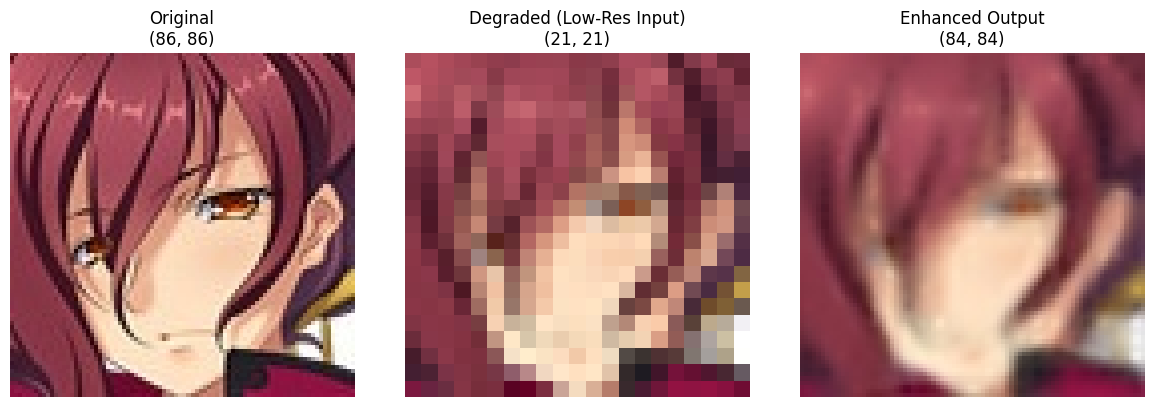

In [12]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Load the pretrained super-resolution model
sr = cv2.dnn_superres.DnnSuperResImpl_create()
sr.readModel("ESPCN_x4.pb")
sr.setModel("espcn", 4)  # "espcn" = model architecture name, 4 = 4x upscaling factor

def enhance_image(pil_image):
    """Takes a PIL image, returns an upscaled (enhanced) PIL image."""
    img_array = np.array(pil_image.convert("RGB"))
    img_bgr = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)  # OpenCV expects BGR, not RGB
    upscaled_bgr = sr.upsample(img_bgr)
    upscaled_rgb = cv2.cvtColor(upscaled_bgr, cv2.COLOR_BGR2RGB)
    return Image.fromarray(upscaled_rgb)

# Test: take a real anime face, deliberately shrink it to simulate a "low-res" input,
# then enhance it and compare against the original
test_files = os.listdir(IMG_DIR)
original = Image.open(os.path.join(IMG_DIR, test_files[0])).convert("RGB")

# Simulate degradation: shrink the image down (this is our "low-res input")
small_size = (original.width // 4, original.height // 4)
degraded = original.resize(small_size, Image.BICUBIC)

# Enhance it back up
enhanced = enhance_image(degraded)

# Display: original vs degraded (low-res input) vs enhanced (our output)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(original)
axes[0].set_title(f"Original\n{original.size}")
axes[0].axis('off')

axes[1].imshow(degraded)
axes[1].set_title(f"Degraded (Low-Res Input)\n{degraded.size}")
axes[1].axis('off')

axes[2].imshow(enhanced)
axes[2].set_title(f"Enhanced Output\n{enhanced.size}")
axes[2].axis('off')

plt.tight_layout()
plt.savefig('enhancement_comparison.png', dpi=150)
plt.show()

In [13]:
def enhance_uploaded_image(uploaded_image):
    """
    Takes a user-uploaded image (any size) and returns an enhanced/upscaled version.
    This is the function the Gradio 'Enhance' tab will call directly on user uploads.
    """
    if uploaded_image is None:
        return None
    return enhance_image(uploaded_image)

# Quick test with the same degraded image from before
test_result = enhance_uploaded_image(degraded)
print("Enhancement function working:", test_result is not None)
print("Output size:", test_result.size)

Enhancement function working: True
Output size: (84, 84)


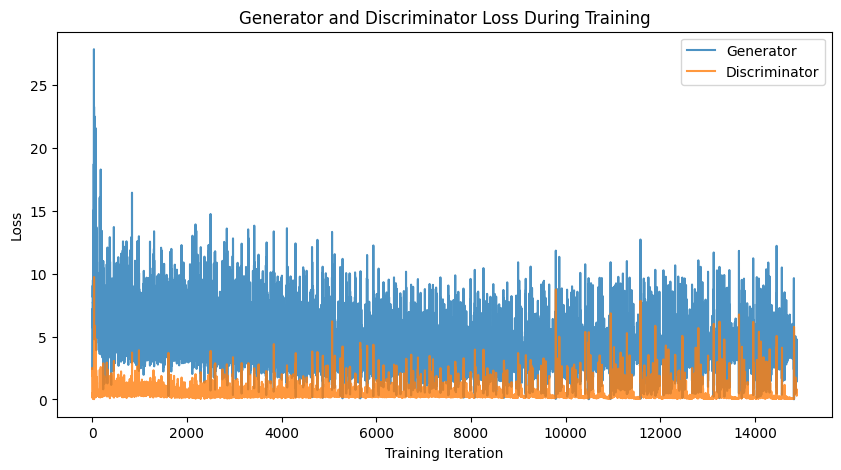

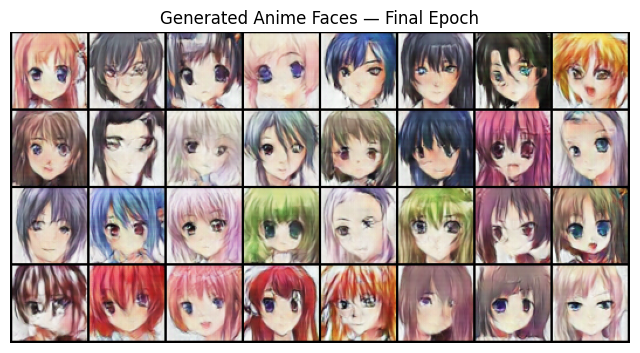

In [14]:
import matplotlib.pyplot as plt

# Plot loss curves
plt.figure(figsize=(10, 5))
plt.plot(G_losses, label="Generator", alpha=0.8)
plt.plot(D_losses, label="Discriminator", alpha=0.8)
plt.xlabel("Training Iteration")
plt.ylabel("Loss")
plt.title("Generator and Discriminator Loss During Training")
plt.legend()
plt.savefig('loss_curves.png', dpi=150)
plt.show()

# Show the final generated faces (from the last checkpoint)
import torchvision.utils as vutils
import numpy as np

final_grid = vutils.make_grid(checkpoint_grids[-1][:32], padding=2, normalize=True)
plt.figure(figsize=(8, 8))
plt.imshow(np.transpose(final_grid, (1, 2, 0)))
plt.axis('off')
plt.title("Generated Anime Faces — Final Epoch")
plt.savefig('final_generated_faces.png', dpi=150)
plt.show()

In [15]:
import torch
torch.save(generator.state_dict(), 'generator.pth')
print("Generator weights saved.")

# Download it to your computer
from google.colab import files
files.download('generator.pth')

Generator weights saved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
!pip install -q pytorch-fid

import os
import torchvision.utils as vutils

# Create folders for real and generated images
os.makedirs('/content/fid_real', exist_ok=True)
os.makedirs('/content/fid_fake', exist_ok=True)

# Save 1000 real images
real_files = os.listdir(IMG_DIR)[:1000]
for i, fname in enumerate(real_files):
    img = Image.open(os.path.join(IMG_DIR, fname)).convert("RGB").resize((64, 64))
    img.save(f'/content/fid_real/{i}.png')

# Generate 1000 fake images using the trained generator
generator.eval()
with torch.no_grad():
    for i in range(0, 1000, 100):  # batches of 100
        noise = torch.randn(100, LATENT_DIM, 1, 1, device=device)
        fakes = generator(noise)
        for j in range(100):
            vutils.save_image(fakes[j], f'/content/fid_fake/{i+j}.png', normalize=True)

print("Real and fake images saved. Computing FID...")

# Compute FID
!python -m pytorch_fid /content/fid_real /content/fid_fake --device cuda

Real and fake images saved. Computing FID...
Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth
100% 91.2M/91.2M [00:00<00:00, 329MB/s]
100% 20/20 [00:05<00:00,  3.78it/s]
100% 20/20 [00:05<00:00,  3.84it/s]
FID:  92.52664604559459


In [ ]:
!pip install -q gradio

import gradio as gr
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
import cv2

# ---- Re-define Generator class (needed to load the saved weights) ----
LATENT_DIM = 100
IMG_CHANNELS = 3
FEATURE_MAP_SIZE = 64

class Generator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, feature_map_size=FEATURE_MAP_SIZE, img_channels=IMG_CHANNELS):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, feature_map_size * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feature_map_size * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(feature_map_size * 8, feature_map_size * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_map_size * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(feature_map_size * 4, feature_map_size * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_map_size * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(feature_map_size * 2, feature_map_size, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_map_size),
            nn.ReLU(True),
            nn.ConvTranspose2d(feature_map_size, img_channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, x):
        return self.main(x)

# ---- Load trained weights ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gen = Generator().to(device)
gen.load_state_dict(torch.load('generator.pth', map_location=device))
gen.eval()

# ---- Load enhancement model ----
sr = cv2.dnn_superres.DnnSuperResImpl_create()
sr.readModel("ESPCN_x4.pb")
sr.setModel("espcn", 4)

# ---- Generation function (seed-based) ----
def generate_face(seed):
    torch.manual_seed(int(seed))
    noise = torch.randn(1, LATENT_DIM, 1, 1, device=device)
    with torch.no_grad():
        fake = gen(noise).cpu().squeeze(0)
    fake = (fake + 1) / 2  # rescale from [-1,1] to [0,1]
    fake = fake.permute(1, 2, 0).numpy() * 255
    return Image.fromarray(fake.astype(np.uint8))

# ---- Random batch generation ----
def generate_batch():
    noise = torch.randn(16, LATENT_DIM, 1, 1, device=device)
    with torch.no_grad():
        fakes = gen(noise).cpu()
    fakes = (fakes + 1) / 2
    images = []
    for i in range(16):
        img = fakes[i].permute(1, 2, 0).numpy() * 255
        images.append(Image.fromarray(img.astype(np.uint8)))
    return images

# ---- Enhancement function ----
def enhance_uploaded(uploaded_image):
    if uploaded_image is None:
        return None
    img_array = np.array(uploaded_image.convert("RGB"))
    img_bgr = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)
    upscaled_bgr = sr.upsample(img_bgr)
    upscaled_rgb = cv2.cvtColor(upscaled_bgr, cv2.COLOR_BGR2RGB)
    return Image.fromarray(upscaled_rgb)

# ---- Build Gradio interface with two tabs ----
with gr.Blocks(title="Anime Face Generator & Enhancer") as demo:
    gr.Markdown("# 🎨 Anime Face Generator & Enhancer")
    gr.Markdown("A DCGAN trained on 63K anime faces, plus an ESPCN-based image enhancer.")

    with gr.Tab("Generate"):
        gr.Markdown("Enter a seed number to generate a specific face (same seed = same face).")
        with gr.Row():
            seed_input = gr.Number(label="Seed", value=42)
            generate_btn = gr.Button("Generate Face")
        output_image = gr.Image(label="Generated Face")
        generate_btn.click(fn=generate_face, inputs=seed_input, outputs=output_image)

        gr.Markdown("---")
        gr.Markdown("Or generate a random batch of 16 faces:")
        batch_btn = gr.Button("Generate Random Batch")
        batch_gallery = gr.Gallery(label="Generated Batch", columns=4)
        batch_btn.click(fn=generate_batch, inputs=None, outputs=batch_gallery)

    with gr.Tab("Enhance"):
        gr.Markdown("Upload a low-resolution or degraded anime image to enhance it.")
        upload_input = gr.Image(label="Upload Image", type="pil")
        enhance_btn = gr.Button("Enhance")
        enhanced_output = gr.Image(label="Enhanced Output")
        enhance_btn.click(fn=enhance_uploaded, inputs=upload_input, outputs=enhanced_output)

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://c3da4a0a58ee491d9f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/usr/local/lib/python3.12/di

In [ ]:
files.download('ESPCN_x4.pb')